In [1]:
#import 
from matplotlib import (pyplot as plt, patches, colors as mplCol)
import numpy as np
import pandas as pd
from astropy.coordinates import (SkyCoord, Distance, Galactic)
from astropy.io import ascii
from astropy import (table, units as u)
from read_mist_models import ISOCMD
import scipy
from astroquery.gaia import Gaia

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


# Load Files Here

In [2]:
path = '../files/'
full_data = pd.read_csv(path + 'photometric_datav4.csv')
print(full_data.columns.to_list())
print(len(full_data))

gaia_ids = str(list(full_data['Gaia DR3 ID'])).strip('[]')


['star', '2MASS ID', 'Gaia DR3 ID', 'AllWISE ID', 'GALEX ID', 'ra', 'dec', 'distance', 'vsini', 'VSX Period', 'Av', 'fe_h', 'm_G', 'Gaia G flux_over_error', 'm_BP', 'Gaia BP flux_over_error', 'm_RP', 'Gaia RP flux_over_error', '2MASS J', '2MASS J error', '2MASS H', '2MASS H error', '2MASS K', '2MASS K error', 'WISE W1', 'WISE W1 error', 'WISE W2', 'WISE W2 error', 'WISE W3', 'WISE W3 error', 'WISE W4', 'WISE W4 error', 'GALEX FUV', 'GALEX FUV Error', 'GALEX NUV', 'GALEX NUV Error', 'Li Profile', 'H-alpha Profile', 'Ca II H Profile', 'Ca II K Profile', '2MASS_qph', 'ALLWISE_ccf', 'ALLWISE_qph', 'leiner_class', 'updated_class']
1895


In [3]:
full_data_concat = full_data[['star',  '2MASS ID','Gaia DR3 ID', 'AllWISE ID', 'GALEX ID', 'vsini', 'VSX Period', 'Av', 
                      '2MASS J', '2MASS J error', '2MASS H', '2MASS H error', '2MASS K', '2MASS K error', 
                     'WISE W1', 'WISE W1 error', 'WISE W2', 'WISE W2 error', 'WISE W3', 'WISE W3 error', 
                     'WISE W4', 'WISE W4 error', 'GALEX FUV', 'GALEX FUV Error', 'GALEX NUV', 'GALEX NUV Error',
                    'Li Profile', 'H-alpha Profile', 
                     'Ca II H Profile', 'Ca II K Profile', '2MASS_qph','ALLWISE_ccf', 'ALLWISE_qph', 
                    'leiner_class', 'updated_class']]
full_data_concat = full_data_concat.rename(columns={'Gaia DR3 ID': 'source_id'})
ffull_data_concat = table.Table.from_pandas(full_data_concat)

In [4]:
query_text = f'''SELECT TOP 10000 source_id, ra, dec, bp_rp, phot_g_mean_mag, 
mh_gspphot, parallax, pmra, pmdec, ruwe,phot_variable_flag, l, b, mh_gspphot_lower, mh_gspphot_upper
FROM gaiadr3.gaia_source 
WHERE gaiadr3.gaia_source.source_id IN ({gaia_ids})'''
job = Gaia.launch_job(query_text) 
gaia_data = job.get_results()

In [5]:
gaia_data = table.join(gaia_data, ffull_data_concat, keys = 'source_id')

In [6]:
gaia_data

source_id,ra,dec,bp_rp,phot_g_mean_mag,mh_gspphot,parallax,pmra,pmdec,ruwe,phot_variable_flag,l,b,mh_gspphot_lower,mh_gspphot_upper,star,2MASS ID,AllWISE ID,GALEX ID,vsini,VSX Period,Av,2MASS J,2MASS J error,2MASS H,2MASS H error,2MASS K,2MASS K error,WISE W1,WISE W1 error,WISE W2,WISE W2 error,WISE W3,WISE W3 error,WISE W4,WISE W4 error,GALEX FUV,GALEX FUV Error,GALEX NUV,GALEX NUV Error,Li Profile,H-alpha Profile,Ca II H Profile,Ca II K Profile,2MASS_qph,ALLWISE_ccf,ALLWISE_qph,leiner_class,updated_class
,deg,deg,mag,mag,dex,mas,mas / yr,mas / yr,,,deg,deg,dex,dex,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,float64,float64,float32,float32,float32,float64,float64,float64,float32,object,float64,float64,float32,float32,str28,str22,str25,str22,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str3,str16,str18,str18,str3,str4,str4,str3,str3
18910470421959808,40.65095558618673,7.290585245493459,1.7245846,8.409346,--,1.9747769984053039,13.376125652744392,-6.101651756946776,2.3110702,NOT_AVAILABLE,164.96390618428475,-46.310843868755356,--,--,HR Cet,2MASS 02423621+0717260,WISEA J024236.23+071726.0,GALEX J024236.2+071726,--,52.84,0.28,6.244,0.021,5.565,0.047,5.245,0.021,5.004,0.234,4.642,0.135,2.719,0.011,1.669,0.017,19.606800079345703,0.1267,16.569900512695312,0.0176999997347593,--,--,--,--,AAA,0000,BBAA,cut,RS
34148700855166720,43.83780066505116,15.656337721802666,1.4843063,10.65428,--,1.2561350761478272,5.895475784371175,-8.513067705308604,1.3987987,NOT_AVAILABLE,161.72312805384962,-37.71082957375897,--,--,DG Ari,2MASS 02552105+1539229,WISEA J025521.06+153922.8,GALEX J025521.0+153923,--,34.02,0.31,8.904,0.046,8.22,0.047,8.061,0.018,7.946,0.026,8.015,0.021,7.907,0.022,7.797,0.211,21.556900024414062,0.3671,18.81760025024414,0.0688999965786933,--,--,--,--,AAA,0000,AAAB,RS,RS
54254958891842816,51.01410355127157,15.47253974991323,1.2839956,14.858748,-0.4777,0.6789366025593843,2.0109631970862374,-2.9367628114152406,0.9188326,VARIABLE,168.53490870847418,-33.56137403732963,-0.5125,-0.4435,CSS J032403.3+152821,2MASS 03240338+1528212,WISEA J032403.38+152821.1,GALEX J032403.3+152821,--,1.07,0.48,13.238,0.022,12.669,0.026,12.534,0.026,12.465,0.024,12.468,0.025,12.21,0.387,8.776,--,--,--,21.83769989013672,0.4056000113487243,--,--,--,--,AAA,0000,AACU,RS,SSG
65719566637012992,58.44664614163716,23.83542417189985,1.2502728,14.168001,-1.4311,0.8194698250657169,-1.1882176389543933,-4.1642186392025735,0.98975843,VARIABLE,168.01300147540084,-22.671361761139675,-1.5112,-1.2486,ZTF J035347.19+235007.6,2MASS 03534721+2350075,WISEA J035347.19+235007.5,--,--,3.88,0.42,12.346,0.021,11.793,0.021,11.658,0.02,11.62,0.024,11.574,0.022,11.368,0.21,8.918,--,--,--,--,--,--,--,--,--,AAA,0000,AABU,RS,SSG
71640436752289408,56.90332442047046,28.10701870991814,1.4130659,15.004778,-0.3814,0.542836491017919,2.3177327580290603,-1.6493144293201751,1.055705,VARIABLE,163.81272542319238,-20.45450759093475,-0.4576,-0.3077,[WM2007] 85,2MASS 03473679+2806253,WISEA J034736.79+280625.2,GALEX J034736.7+280625,--,2.68,0.37,13.108,0.024,12.483,0.025,12.381,0.025,12.319,0.024,12.285,0.024,12.426,0.528,9.034,--,--,--,21.42569923400879,0.4990000128746032,--,--,--,--,AAA,0000,AACU,RS,SSG
81709523719057536,40.68759334849107,16.305496512913244,1.2449026,14.471627,-0.5055,0.740113509934223,10.778416626042775,-18.00096982448213,0.9676194,VARIABLE,158.05729755082763,-38.857408287038616,-0.5316,-0.4806,ZTF J024245.02+161819.8,2MASS 02424501+1618200,WISEA J024245.01+161819.9,GALEX J024245.0+161820,--,6.33,0.26,12.942,0.021,12.341,0.023,12.22,0.017,12.193,0.023,12.144,0.023,11.828,0.323,8.834,--,--,--,21.0802001953125,0.2273000031709671,--,--,--,--,AAA,0000,AABU,RS,SSG
83339790224838784,41.88059999692063,17.268300455125537,1.2951889,13.467905,-0.1972,1.1448237973359252,-0.4759824178934202,-9.750861342023375,0.96254027,NOT_AVAILABLE,158.62152112316838,-37.43100709386514,-0.2186,-0.1756

In [7]:
c = SkyCoord(ra=gaia_data['ra'], dec=gaia_data['dec'], frame='icrs')
ra = c.ra.wrap_at(180 * u.deg).radian
dec = c.dec.radian
metallicity = np.array(gaia_data['mh_gspphot'], dtype = float) #Metallicity

distance = np.array(Distance(parallax=u.Quantity(gaia_data['parallax'])),
                    dtype = float)

m_G = np.array(gaia_data['phot_g_mean_mag'], dtype = float)
uncorr_bp_rp = np.array(gaia_data['bp_rp'], dtype = float)

In [8]:
#Periods
periods = np.array(gaia_data['VSX Period'], dtype=float)
#Reddening
#av_tot = np.genfromtxt(file, usecols=16, dtype=float)

av = np.array(gaia_data['Av'], dtype = float)
ag = av*0.789
Ebp_rp = ag/1.890 #ag/e(bp=rp) = 1.890
bp_rp = uncorr_bp_rp - Ebp_rp
M_G = -5*np.log10(distance) + m_G + ag + 5 #m-M = 5log(d) - 5 + Av

#m - M + Av = 5log(d)
#M = m + Av -5log(d)


#Add to gaia_table
gaia_data['(bp-rp)_0'] = bp_rp
gaia_data['M_G'] = M_G

C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:3710: RuntimeWarning: invalid value encountered in divide
  return sin(y)/y


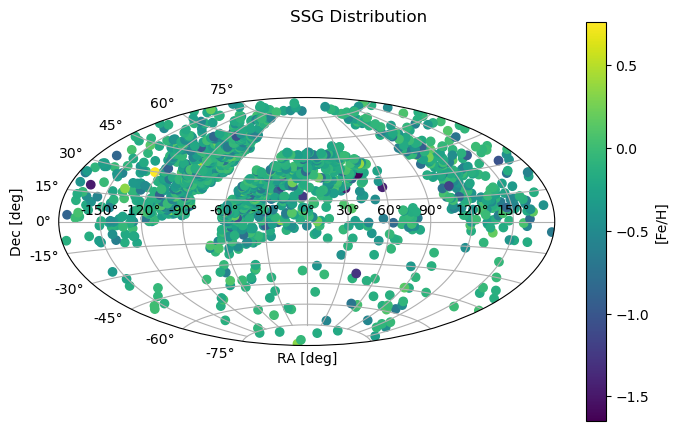

In [9]:
#Test Global Map
fig, ax = plt.subplots(figsize=(8,4.2), 
                       subplot_kw=dict(projection="aitoff"))
fig.suptitle('SSG Distribution')
cs = ax.scatter(ra, dec, c=metallicity)


ax.grid()

cb = fig.colorbar(cs)

cb.set_label('[Fe/H]')
#mpl.cm.set_clim.cb(vmax = 0.25) 
ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
fig.subplots_adjust(top=0.95,bottom=0.0)

Text(0, 0.5, 'Number of Stars')

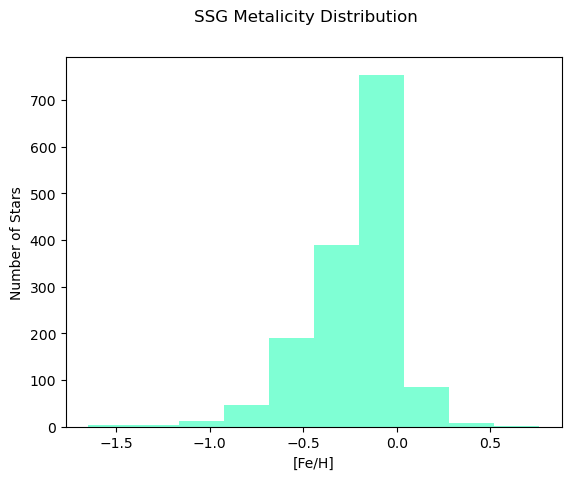

In [10]:
plt.hist(metallicity, color = 'aquamarine')
plt.suptitle('SSG Metalicity Distribution')
plt.xlabel("[Fe/H]")
plt.ylabel("Number of Stars")

In [11]:
print(min(metallicity[metallicity > -999]))
print(max(metallicity[metallicity > -999]))

-1.648800015449524
0.7620000243186951


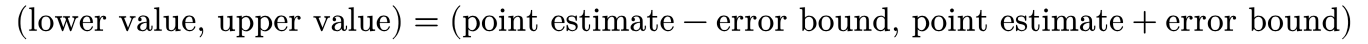

# Isochrones

In [12]:
iso_path = '../files/isochrones/'
def isochrone_opener(iso_file):
    iso_plot = ISOCMD(iso_file)
    G = iso_plot.isocmds[0]['Gaia_G_EDR3']
    BP_RP = iso_plot.isocmds[0]['Gaia_BP_EDR3'] - iso_plot.isocmds[0]['Gaia_RP_EDR3']
    return G, BP_RP

G_05, BP_RP05 = isochrone_opener(iso_path + r'MIST_iso_4_gyr_feh_0.5.iso.cmd')
G_00, BP_RP00 = isochrone_opener(iso_path + r'MIST_iso_14_gyr_feh_0.0.iso.cmd')
G_low01, BP_RPlow01 = isochrone_opener(iso_path + 'MIST_iso_14_gyr_feh_low_0.1.iso.cmd')
G_low03, BP_RPlow03= isochrone_opener(iso_path + 'MIST_iso_14_gyr_feh_low_0.3.iso.cmd')
G_low025, BP_RP_low025 = isochrone_opener(iso_path + r'MIST_iso_14_gyr_feh_low_0.25.iso.cmd')
G_low05, BP_RPlow05 = isochrone_opener(iso_path + 'files/isochrones/MIST_iso_14_gyr_feh_low_0.5.iso.cmd')

Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.5.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_0.0.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.1.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.3.iso.cmd
Reading in: files/isochrones/duplicates/MIST_iso_14_gyr_feh_low_0.25.iso.cmd
Reading in: files/isochrones/MIST_iso_14_gyr_feh_low_0.5.iso.cmd


In [13]:
#Compare isocrone for all
#Once you have calculated M_G and BP_RP above,

#highlight HU Vir, FN Com
HUVir = gaia_data['source_id'] == 3582095053777917952 #HU Vir
FNCom = gaia_data['source_id'] == 3947234928261838720 #FN Com
Dra29 = gaia_data['source_id'] == 1655646778064790528 #1655646778064790528 #29 Dra 1655646778064790528
NSVS14892045 = (gaia_data['source_id'] == 3178786251609990656)

#Defining metallicty samples
fe_h1b = (metallicity > 0.0)
fe_h2b = (metallicity <= 0.0) & (metallicity > -0.25)
fe_h3b = (metallicity <= -0.25) & (metallicity >= -100)

valid_feh = (metallicity > -9999)

# CMDs

----------------------------- Full Sample ----------------------------------------------
Original: 448 or 24%
Current: 1279 or 67%
Total Size: 1895
----------------------------- With Valid [Fe/H] data ------------------------------------
Original: 448 or 30%
Current: 1167 or 78%
Total Size: 1494


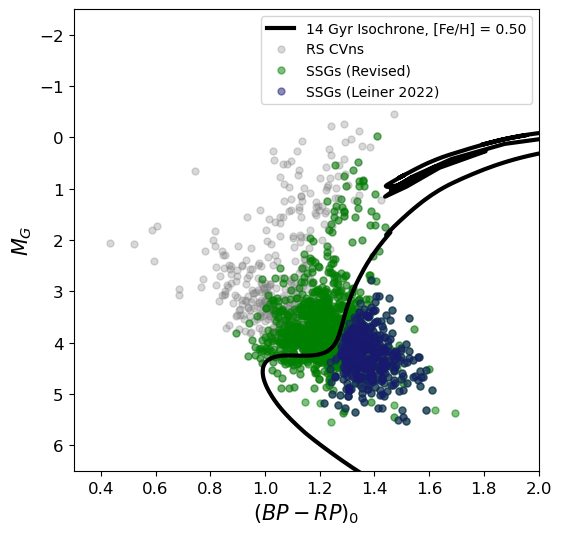

In [14]:
#raw_leiner2022_class = np.genfromtxt(file, usecols=17, dtype=str)
leiner2022_class = np.array(gaia_data['leiner_class'], dtype=str)

original_ssg = (leiner2022_class == 'SSG')

metal_rich = ((fe_h1b == True) | valid_feh == False)

ssgs = (gaia_data['updated_class'] == 'SSG')
RS = (gaia_data['updated_class'] == 'RS')

fig, ax = plt.subplots(1, figsize=(6,6))
ax.plot(BP_RP05, G_05, color = 'black', 
        label='14 Gyr Isochrone, [Fe/H] = 0.50', zorder=10, lw=3)
ax.plot(bp_rp[valid_feh], M_G[valid_feh],
        marker='o', linestyle='none', alpha=0.3,
        color = 'gray', label = 'RS CVns', ms=5)#, color = 'darkmagenta')
ax.plot(bp_rp[ssgs], M_G[ssgs],
        marker='o', linestyle='none', alpha=0.5, 
        color = 'green', label = 'SSGs (Revised)', ms=5)

ax.plot(bp_rp[original_ssg], M_G[original_ssg],
        marker='o', linestyle='none', alpha=0.5, 
        color = 'midnightblue', label = 'SSGs (Leiner 2022)', ms=5)

ax.set_xlim(0.3, 2)
ax.set_ylim(-2.5,6.5)
ax.invert_yaxis()
ax.set_xlabel('$(BP-RP)_0$', fontsize=15)
ax.set_ylabel('$M_G$',fontsize=15)
ax.legend()
ax.tick_params(axis='x', labelsize=12)  # X-axis tick labels
ax.tick_params(axis='y', labelsize=12)


def frac(a,b):
    d = a/b * 100
    return round(d)


print('----------------------------- Full Sample ----------------------------------------------')
print('Original:', len(bp_rp[original_ssg]), 'or', str(frac(len(bp_rp[original_ssg]), len(bp_rp))) + '%')
print('Current:', len(bp_rp[ssgs]), 'or', str(frac(len(bp_rp[ssgs]), len(bp_rp))) + '%')
print('Total Size:', len(bp_rp))
print('----------------------------- With Valid [Fe/H] data ------------------------------------')
print('Original:', len(bp_rp[original_ssg]), 'or', str(frac(len(bp_rp[original_ssg]), len(bp_rp[valid_feh]))) + '%')
print('Current:', len(bp_rp[ssgs & valid_feh]), 'or', str(frac(len(bp_rp[ssgs & valid_feh]), len(bp_rp[valid_feh]))) + '%')
print('Total Size:', len(bp_rp[valid_feh]))

fig_path_comp = r'CMDs\ssg_comparison.png'
#fig.savefig(fig_path_comp, dpi = 300)

#print(len(bp_rp[]))

In [15]:
def four_plots(xlim = (0, 2.60), ylim = (-2.5,6.5), alpha = 0.1,
               label = None, sec_filt = np.ones(len(gaia_data), dtype = bool),
              bp_rp_label = '$(BP-RP)_0$'):
    '''
    Creates the background plots
    
    '''
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    (ax, ax2), (ax3, ax4) = axes
    
    #full Sample
    ax.set_title('Full CMD')
    ax.plot(bp_rp[valid_feh & sec_filt], M_G[valid_feh & sec_filt],
            marker='.', linestyle='none', alpha= alpha,color = 'gray', label = label)#'RS CVns')
    
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.invert_yaxis()
    ax.set_xlabel(bp_rp_label)
    ax.set_ylabel('$M_G$')
    ax.legend()

    #Subsample 1
    ax2.plot(BP_RP05, G_05, color = 'black', label='14 Gyr Isochrone, [Fe/H] = 0.50')
    ax2.set_title(r'[Fe/H] > 0.0')
    ax2.plot(bp_rp[fe_h1b & sec_filt], M_G[fe_h1b & sec_filt],
             marker='.', linestyle='none', alpha=alpha,color = 'gray')#, color = 'darkmagenta')
    
    ax2.set_xlim(xlim[0], xlim[1])
    ax2.set_ylim(ylim[0], ylim[1])
    ax2.invert_yaxis()
    ax2.set_xlabel(bp_rp_label)
    ax2.set_ylabel('$M_G$')
    ax2.legend()

    #Subsample 2
    ax3.set_title(r'-0.25 < [Fe/H] $\leq$ 0.00')
    ax3.plot(BP_RP00, G_00, color = 'black', label='14 Gyr Isochrone, [Fe/H] = 0.00')
    ax3.plot(BP_RP05, G_05, color = 'blue', linestyle = '--', label='14 Gyr Isochrone, [Fe/H] = 0.50')
    ax3.plot(bp_rp[fe_h2b & sec_filt], M_G[fe_h2b & sec_filt], 
                 marker='.', linestyle='none', alpha=alpha, color = 'gray')#, color = 'darkcyan')

    ax3.set_xlim(xlim[0], xlim[1])
    ax3.set_ylim(ylim[0], ylim[1])
    ax3.invert_yaxis()
    ax3.set_xlabel(bp_rp_label)
    ax3.set_ylabel('$M_G$')
    
    ax3.legend()

    #Subsample 3
    ax4.set_title(r'[Fe/H] $\leq$ -0.25')
    ax4.plot(BP_RP_low025, G_low025, color = 'black', label='14 Gyr Isochrone, [Fe/H] = -0.25')
    ax4.plot(BP_RP05, G_05, color = 'blue', linestyle = '--', label='14 Gyr Isochrone, [Fe/H] = 0.50')
    ax4.plot(bp_rp[fe_h3b & sec_filt], M_G[fe_h3b & sec_filt],
             marker='.', linestyle='none', alpha=alpha, color = 'gray')
    ax4.set_xlim(xlim[0], xlim[1])
    ax4.set_ylim(ylim[0], ylim[1])
    ax4.invert_yaxis()
    ax4.set_xlabel(bp_rp_label)
    ax4.set_ylabel('$M_G$')
    ax4.legend()
    
    
    return fig, ((ax, ax2), (ax3, ax4))



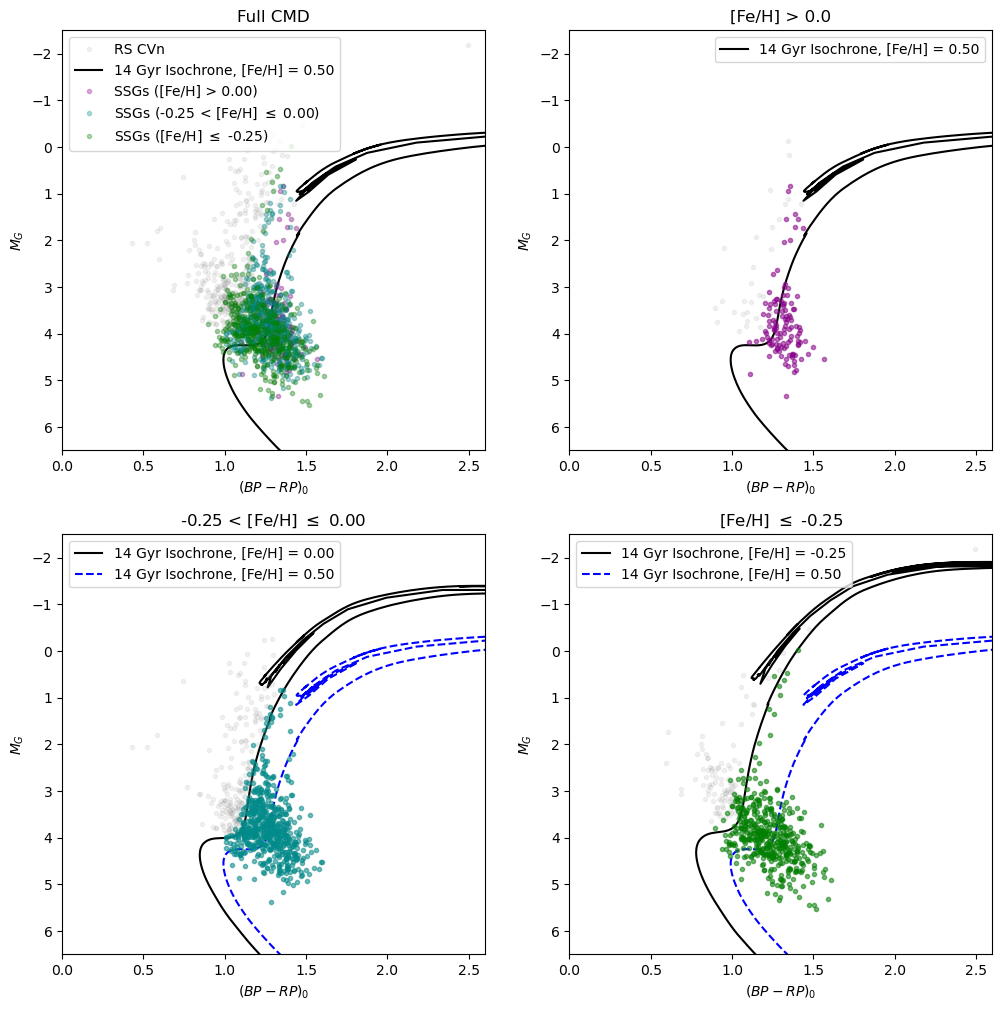

In [16]:
notable_stars = (HUVir | FNCom | NSVS14892045)

fig, axes = four_plots(label = 'RS CVn', xlim=(0,2.6))

(ax, ax2), (ax3, ax4) = axes

#Full CMD
ax.plot(BP_RP05, G_05, color = 'black', label='14 Gyr Isochrone, [Fe/H] = 0.50')


ax.plot(bp_rp[fe_h1b & ssgs], M_G[fe_h1b & ssgs], marker='.', linestyle='none', 
        alpha=0.3, color = 'darkmagenta', label = 'SSGs ([Fe/H] > 0.00)')
ax.plot(bp_rp[fe_h2b & ssgs], M_G[fe_h2b & ssgs], marker='.', linestyle='none', 
        alpha=0.3, color = 'darkcyan', label = 'SSGs (-0.25 < [Fe/H] $\leq$ 0.00)')
ax.plot(bp_rp[fe_h3b & ssgs], M_G[fe_h3b & ssgs], marker='.', linestyle='none', 
        alpha=0.3, color = 'green', label = 'SSGs ([Fe/H] $\leq$ -0.25)')
ax.legend()
'''
ax.scatter(bp_rp[notable_stars], M_G[notable_stars], marker='*', color = 'blue', s=40, zorder=10)

ax.text(bp_rp[HUVir], M_G[HUVir], 'HU Vir')
ax.text(bp_rp[FNCom], M_G[FNCom], 'FNCom')
ax.text(bp_rp[NSVS14892045], M_G[NSVS14892045], 'NSVS 14892045', ha = 'right')
'''

#Subsample 1
ax2.plot(bp_rp[fe_h1b & ssgs], M_G[fe_h1b & ssgs],
        marker='.', linestyle='none', alpha=0.5, color = 'darkmagenta')

#Subsample 2
ax3.plot(bp_rp[fe_h2b & ssgs], M_G[fe_h2b & ssgs], 
             marker='.', linestyle='none', alpha=0.5, color = 'darkcyan')
'''
ax3.scatter(bp_rp[notable_stars], M_G[notable_stars], 
            marker='*', color = 'blue', s=40, zorder=10
ax3.text(bp_rp[HUVir], M_G[HUVir], 'HU Vir')
ax3.text(bp_rp[FNCom], M_G[FNCom], 'FNCom')
ax3.text(bp_rp[NSVS14892045], M_G[NSVS14892045], 'NSVS 14892045', ha = 'right')
'''
#Subsample 3
ax4.plot(bp_rp[fe_h3b & ssgs], M_G[fe_h3b & ssgs],
             marker='.', linestyle='none', alpha=0.5, color = 'green')

fig.savefig(r'CMDs\feh_bins.png', dpi=300)

In [17]:
print('NSVS14892045', metallicity[NSVS14892045])
print('FN Com', metallicity[FNCom])
print('HU Vir', metallicity[HUVir])

NSVS14892045 [-0.1592]
FN Com [nan]
HU Vir [-0.13150001]


# Find SSG Fraction

In [18]:
problema = (original_ssg & (ssgs == False))
print(gaia_data[problema]['source_id'])

problem_list = [595725295534806912, 1325511471158784128, 3638205709122491264, 6914639412301202048]
problem_filt = np.array([True if item in problem_list else False for item in gaia_data['source_id']])

ssgs[problem_filt] = True #remove problem objects
del problem_list, problem_filt, problema

source_id
---------


In [19]:
print('NSVS 14892045 ---', 
      'l:', gaia_data['l'][NSVS14892045][0],',', 
      'b: ', gaia_data['b'][NSVS14892045][0])

NSVS 14892045 --- l: 206.4102022076443 , b:  -39.211245950031156


# Spectrocopic Sample Analysis

In [20]:
ssg_profile = np.array(gaia_data['H-alpha Profile'], dtype = str)
ssg_name = np.array(gaia_data['star'], dtype = str)

In [21]:
#Defining metallicty samples
variable_ha = (ssg_profile == 'Variable H-alpha')
absorption = (ssg_profile == 'Absorption')
emission = (ssg_profile == 'Emission')
#colors
emis_color = 'green'
abs_color = 'darkmagenta'
var_color = 'darkcyan'

In [22]:
def Halpha_plots(ax, filters, colors = (abs_color, emis_color, var_color), 
                 legend = True, labels = ('Absorption', 'Emission', 'Variable H-alpha')):
    ax.plot(bp_rp[absorption & filters], M_G[absorption & filters], 
                 marker='P', linestyle='none', alpha=0.7, color = colors[0], label = labels[0])
    ax.plot(bp_rp[emission & filters], M_G[emission & filters], 
                 marker='v', linestyle='none', alpha=0.7, color = colors[1], label = labels[1])
    ax.plot(bp_rp[variable_ha & filters], M_G[variable_ha & filters], 
                 marker='X', linestyle='none', alpha=0.7, color = colors[2], label = labels[2])
    if legend == True:
        ax.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


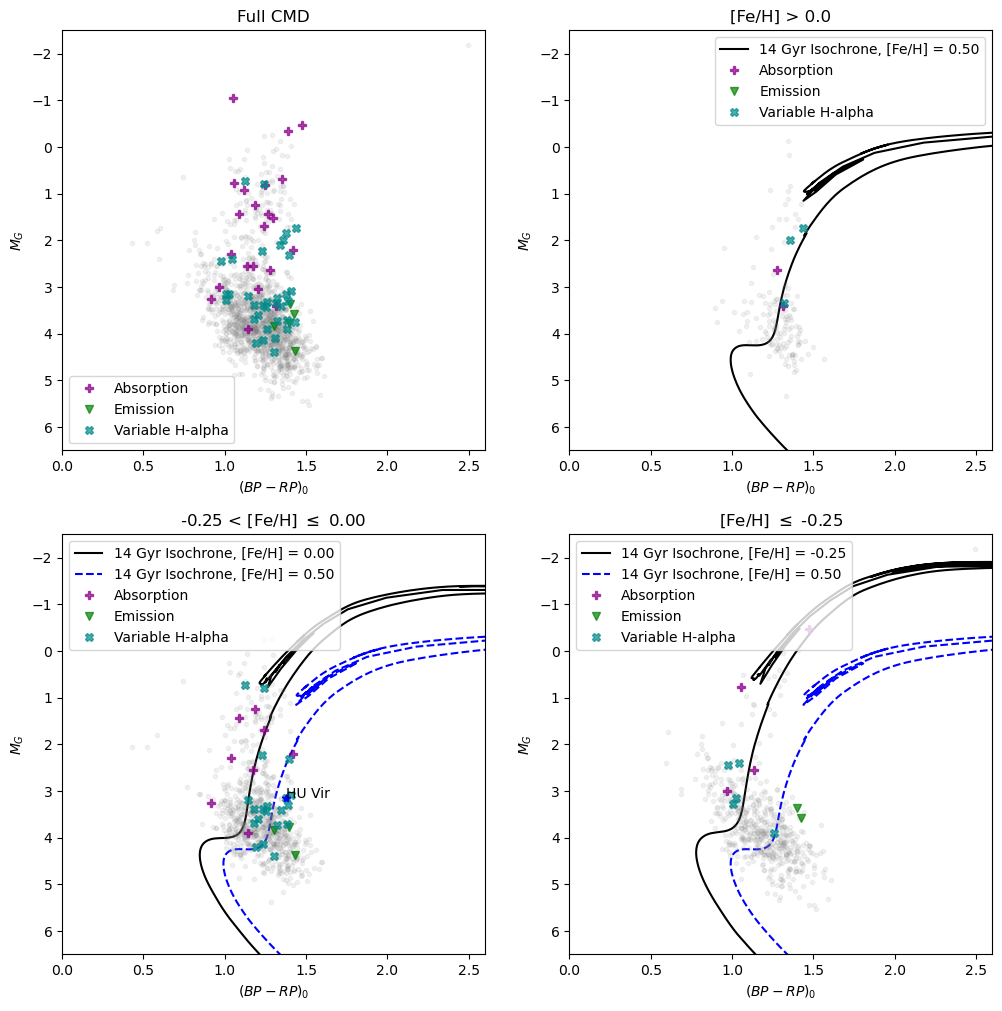

In [23]:
true_arr = np.full(len(bp_rp), True)

fig, axes = four_plots()
(ax, ax2), (ax3, ax4) = axes
#Full Sample
Halpha_plots(ax, filters=true_arr)
#Subsample #1
Halpha_plots(ax2, fe_h1b)

#Subsample #2
Halpha_plots(ax3, fe_h2b)
#Highlight Stars
ax3.plot(bp_rp[HUVir], M_G[HUVir], marker='*', linestyle='none', 
        alpha=1, color = 'blue')
ax3.text(bp_rp[HUVir], M_G[HUVir], 'HU Vir')

#Subsample #3
Halpha_plots(ax4,fe_h3b)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


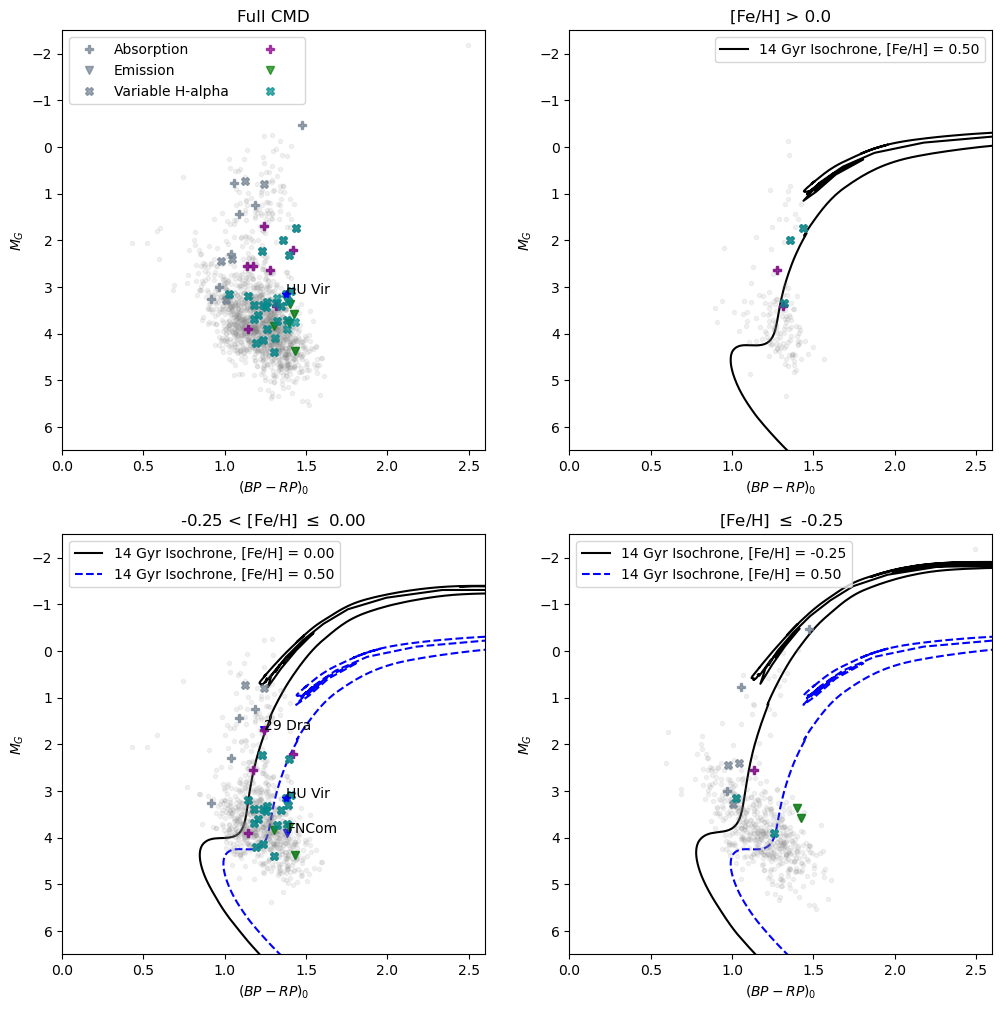

In [24]:
Halpha_ssgs = ((absorption & ssgs) | (emission & ssgs) | (ssgs & variable_ha))
grey_filt = ('slategrey', 'slategrey', 'slategrey')

size = 30
fig, axes = four_plots()
(ax, ax2), (ax3, ax4) = axes
#Full Sample
Halpha_plots(ax, filters=valid_feh,colors = grey_filt, 
             legend = True)
Halpha_plots(ax, filters=Halpha_ssgs, labels = [' ', ' ',' '])

ax.plot(bp_rp[HUVir], M_G[HUVir], marker='*', linestyle='none', 
        alpha=1, color = 'blue')
ax.text(bp_rp[HUVir], M_G[HUVir], 'HU Vir')

#Subsample #1
Halpha_plots(ax2, fe_h1b, colors = grey_filt, 
             legend = False, labels = [None, None,None])
Halpha_plots(ax2, fe_h1b & Halpha_ssgs, legend = False)

#Subsample #2
Halpha_plots(ax3, fe_h2b, colors = grey_filt, 
             legend = False, labels = [None, None,None])
Halpha_plots(ax3, fe_h2b & Halpha_ssgs, legend = False)

#Highlight Stars
ax3.plot(bp_rp[HUVir], M_G[HUVir], marker='*', linestyle='none', 
        alpha=1, color = 'blue')
ax3.text(bp_rp[HUVir], M_G[HUVir], 'HU Vir')


ax3.scatter(bp_rp[Dra29], M_G[Dra29], marker = 'v', s = size, alpha = 1, color = 'blue')
ax3.text(bp_rp[Dra29], M_G[Dra29], '29 Dra')

ax3.scatter(bp_rp[FNCom], M_G[FNCom], marker = 'v', s = size, alpha = 1, color = 'blue')
ax3.text(bp_rp[FNCom], M_G[FNCom], 'FNCom')
#Subsample #3
Halpha_plots(ax4, fe_h3b, colors = ('slategrey', 'slategrey', 'slategrey'), legend = False)
Halpha_plots(ax4,fe_h3b & Halpha_ssgs, legend = False)
ax.legend(ncols = 2)


In [25]:
print('variable ha:', len(gaia_data[variable_ha & ssgs])/len(gaia_data[variable_ha]))
print('emiss:',len(gaia_data[emission & ssgs])/len(gaia_data[emission]))
print('absorb:', len(gaia_data[absorption & ssgs])/len(gaia_data[absorption]))

variable ha: 0.7714285714285715
emiss: 1.0
absorb: 0.3181818181818182


(-1.0, 40.0)

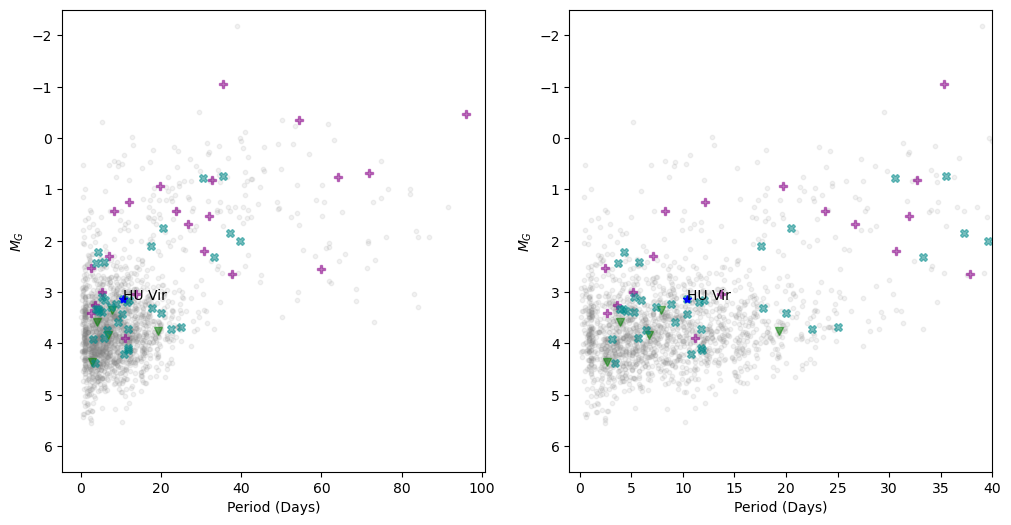

In [26]:
def period_plt(ax, highlight_star = True):
    ax.scatter(periods, M_G, s=10, color = 'grey', alpha = 0.1)#, vmax=30)

    ax.plot(periods[absorption], M_G[absorption], marker='P', linestyle='none', 
            alpha=0.5, color = abs_color, label = 'Absorption')
    ax.plot(periods[emission], M_G[emission], marker='v', linestyle='none', 
            alpha=0.5, color = emis_color, label = 'Emission')
    ax.plot(periods[variable_ha], M_G[variable_ha], marker='X', linestyle='none', 
            alpha=0.5, color = var_color, label = 'Variable H-alpha')
    ax.set_ylim(-2.5,6.5)
    
    if highlight_star == True:
        ax.plot(periods[HUVir], M_G[HUVir], marker='*', linestyle='none', color='b', alpha = 1.0)
        ax.text(periods[HUVir], M_G[HUVir], 'HU Vir')
        ax.invert_yaxis()
    ax.set_xlabel('Period (Days)')
    ax.set_ylabel('$M_G$')
    
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 6))
period_plt(ax = ax)
period_plt(ax = ax2)
ax2.set_xlim(-1, 40)

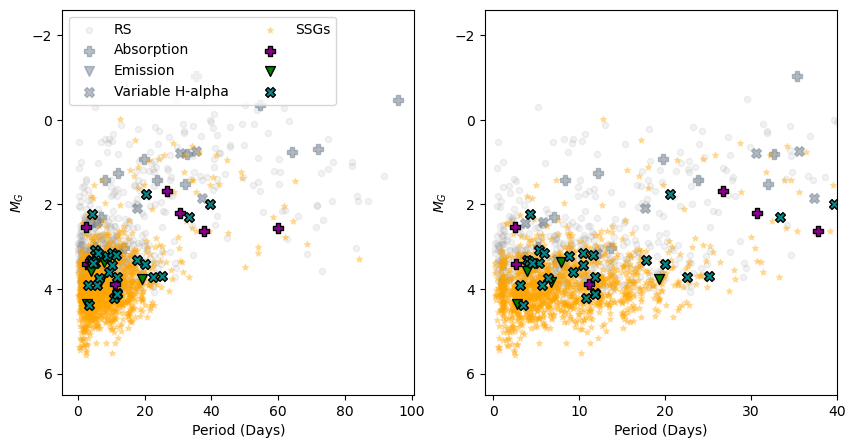

In [28]:

def period_plt2(ax):
    ax.scatter(periods[RS], M_G[RS], s=20, color = 'grey', alpha = 0.1, label = 'RS')
    ax.scatter(periods[absorption & RS], M_G[absorption & RS], marker='P', s=50, 
                alpha=0.5, color = 'slategrey', label = 'Absorption')
    ax.scatter(periods[emission & RS], M_G[emission & RS], marker='v', s=50, 
                alpha=0.5, color = 'slategrey', label = 'Emission')
    ax.scatter(periods[variable_ha & RS], M_G[variable_ha & RS], marker='X', s=50, 
                alpha=0.5, color = 'slategrey', label = 'Variable H-alpha')

    ax.scatter(periods[ssgs], M_G[ssgs], s=20, color = 'orange', 
               alpha = 0.3, marker = '*', label = 'SSGs')
    ax.scatter(periods[absorption & ssgs], M_G[absorption & ssgs], marker='P', s=50, 
                alpha=1, color = abs_color, label = ' ', edgecolor = 'black')
    ax.scatter(periods[emission & ssgs], M_G[emission & ssgs], marker='v', s = 50,
                alpha=1, color = emis_color, label = ' ', edgecolor = 'black')
    ax.scatter(periods[variable_ha & ssgs], M_G[variable_ha & ssgs], marker='X', s=50,
                alpha=1, color = var_color, label = ' ', edgecolor = 'black')
    ax.set_ylim(-2.6,6.5)

    ax.invert_yaxis()
    ax.set_xlabel('Period (Days)')
    ax.set_ylabel('$M_G$')

fig, (ax,ax2) = plt.subplots(1,2, figsize=(10,5))    
period_plt2(ax = ax)
period_plt2(ax = ax2)
ax2.set_xlim(-1, 40)
ax.legend(ncols=2)
#
fig.savefig(r'CMDS\period_magnitude_plt.png', dpi=300)

Text(0, 0.5, '$M_G$')

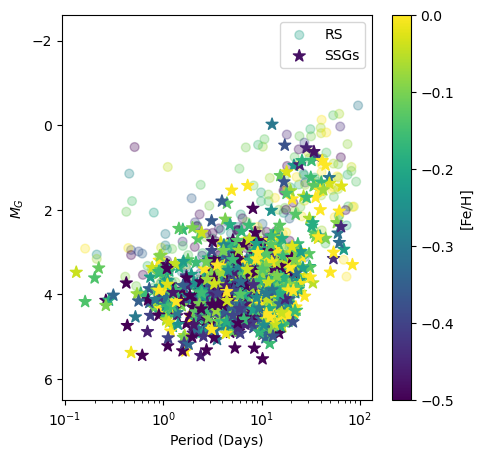

In [50]:

fig, ax = plt.subplots(1, figsize=(5,5))    
ax.scatter(periods[RS & valid_feh], M_G[RS & valid_feh], s=40,
           c = metallicity[RS & valid_feh], vmin = -0.5, vmax = 0, 
           alpha = 0.3, label = 'RS')

cs = ax.scatter(periods[ssgs & valid_feh], M_G[ssgs & valid_feh], s=80, 
           c = metallicity[ssgs & valid_feh], vmax = 0, vmin = -0.5, 
           marker = '*', label = 'SSGs')

cb = fig.colorbar(cs, ax=ax)
cb.set_label('[Fe/H]')


ax.set_ylim(-2.6,6.5)
#ax.set_xlim(left=1)
ax.set_xscale('log')
ax.invert_yaxis()
ax.legend()
ax.set_xlabel('Period (Days)')
ax.set_ylabel('$M_G$')



# RV Sample

In [28]:
rv_samp_file = path + r'rv_summary_table_v4.tex'

rv_data = ascii.read(rv_samp_file, format = 'latex')
rv_data.rename_column('Gaia DR3', 'source_id')
rv_data['source_id'] = np.array(rv_data['source_id'], dtype = np.int64)
rv_data['K1'] = np.array([float(item[1::].split('^')[0]) for item in rv_data['K1']])
rv_data['K2'] = np.array([float(item[1::].split('^')[0])
                          if item != "---" else np.nan 
                          for item in rv_data['K2']])
rv_data['in_rv_samp'] = True

In [29]:
rv_data2 = table.join(rv_data, gaia_data, 'source_id', keep_order=True, join_type='left')
rv_data2

Star ID,source_id,N_obs,K1,K2,Updated Class,Broadening Profile,in_rv_samp,ra,dec,bp_rp,phot_g_mean_mag,mh_gspphot,parallax,pmra,pmdec,ruwe,phot_variable_flag,l,b,mh_gspphot_lower,mh_gspphot_upper,star,2MASS ID,AllWISE ID,GALEX ID,vsini,VSX Period,Av,2MASS J,2MASS J error,2MASS H,2MASS H error,2MASS K,2MASS K error,WISE W1,WISE W1 error,WISE W2,WISE W2 error,WISE W3,WISE W3 error,WISE W4,WISE W4 error,GALEX FUV,GALEX FUV Error,GALEX NUV,GALEX NUV Error,Li Profile,H-alpha Profile,Ca II H Profile,Ca II K Profile,2MASS_qph,ALLWISE_ccf,ALLWISE_qph,leiner_class,updated_class,(bp-rp)_0,M_G
,,,,,,,,deg,deg,mag,mag,dex,mas,mas / yr,mas / yr,,,deg,deg,dex,dex,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
str26,int64,int64,float64,float64,str6,str10,bool,float64,float64,float32,float32,float32,float64,float64,float64,float32,object,float64,float64,float32,float32,str28,str22,str25,str22,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str3,str16,str18,str18,str3,str4,str4,str3,str3,float64,float64
29 Dra,1655646778064790528,5,0.99,nan,SSG,SB1,True,263.17063429405675,74.22749068131633,1.2794647,6.2837353,-0.0535,11.636431640136372,-67.01419431036842,29.732148430441374,17.799063,NOT_AVAILABLE,105.49292080222743,31.353682752479607,-0.0549,-0.0519,29 Dra,2MASS 17324120+7413383,WISEA J173241.11+741338.3,GALEX J173240.9+741340,8.1356,26.74,0.09,4.923,0.256,4.218,0.248,4.09,0.396,4.112,0.282,3.774,0.184,4.094,0.027,3.878,0.023,13.520400047302246,0.01,13.208100318908691,0.0035999999381601,Yes,Absorption,Normal Emission,Normal Emission,DDD,HHH0,BBAA,cut,SSG,1.241893293108259,1.6838443879256162
2MASS J08171221+0736164,3097200805201566720,4,12.75,nan,---,SB1,True,124.30091114910356,7.604554583632012,1.4130526,10.956055,--,0.5361421397818906,1.269924398390016,-0.20008775263906636,1.0080758,VARIABLE,215.87558468701062,22.50825130710697,--,--,2MASS J08171221+0736164,2MASS 08171221+0736164,WISEA J081712.21+073616.4,GALEX J081712.1+073616,15.16525,54.45,0.06,9.127,0.021,8.475,0.029,8.352,0.031,8.296,0.023,8.374,0.021,8.258,0.024,8.391,0.338,22.148099899291992,0.4,18.746299743652344,0.048200000077486,Yes,Absorption,Variable,Normal Emission,AAA,0000,AAAB,RS,RS,1.3880049398513068,-0.350205595945285
2MASS J08504952+1217158,605014833054650880,4,18.1,4.97,---,SB2,True,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--
2MASS J17270871+2700144,4571134418985782912,3,3.49,nan,SSG,SB1,True,261.78625167997257,27.00397750271015,1.1840992,11.918881,-0.3095,1.2817469410216429,-8.500586303659343,-9.163273644479563,1.0172812,VARIABLE,50.173716584307904,29.48244353992647,-0.3228,-0.2959,2MASS J17270871+2700144,2MASS 17270871+2700144,WISEA J172708.70+270014.3,--,4.114666666666667,59.89,0.12,10.491,0.026,9.901,0.031,9.852,0.022,9.716,0.022,9.772,0.02,9.711,0.043,8.882,--,--,--,--,--,Yes,Absorption,Normal Emission,Normal Emission,AAA,0000,AAAU,RS,SSG,1.1340039592924571,2.5525728645190067
54 Cam,1081565094046074624,5,49.19,48.59,---,SB2,True,120.64879587450116,57.27336257313166,0.8229718,6.3329296,--,10.041266798275789,-36.659447205181564,-59.36361871912946,1.2820733,NOT_AVAILABLE,160.328301267592,32.04615678023573,--,--,54 Cam,2MASS 08023579+5716252,WISEA J080235.75+571624.5,--,12.888666666666667,10.1,0.1,5.274,0.017,4.931,0.042,4.864,0.02,4.869,0.189,4.667,0.105,4.86,0.015,4.792,0.029,--,--,--,--,Yes,SB2,None/To Noisy,None/To Noisy,EAA,0000,BAAA,RS,RS,0.7812257890852671,1.4207721437746157
ASAS J073642+0354.3,3137895792132452736,8,0.58,nan,SSG,SB1,True,114.17451836544072,3.9055072929621564,1.450098,11.391968,-0.1016,2.8415429349658576,-17.48261169433535,0.9957190592995506,0.8629138,VARIABLE,214.60879770824073,11.845356565394061,-0.1066,-0.0982,ASAS J073642+0354.3,2MASS 07364190+0354199,WISEA J073641.89+035419.8,--,8.370625,19.28,0.13,9.152,0.02,8.568,0.057,8.386,0.026,8

In [30]:
rv_data2 = rv_data2.to_pandas()
rv_data2.to_csv(r'files\rv_samples_with_corr.csv', index = False)

In [49]:
gaia_data = table.join(gaia_data, rv_data, 'source_id', keep_order=True, join_type='left')
gaia_data

source_id,ra,dec,bp_rp,phot_g_mean_mag,mh_gspphot,parallax,pmra,pmdec,ruwe,phot_variable_flag,l,b,mh_gspphot_lower,mh_gspphot_upper,star,2MASS ID,AllWISE ID,GALEX ID,vsini,VSX Period,Av,2MASS J,2MASS J error,2MASS H,2MASS H error,2MASS K,2MASS K error,WISE W1,WISE W1 error,WISE W2,WISE W2 error,WISE W3,WISE W3 error,WISE W4,WISE W4 error,GALEX FUV,GALEX FUV Error,GALEX NUV,GALEX NUV Error,Li Profile,H-alpha Profile,Ca II H Profile,Ca II K Profile,2MASS_qph,ALLWISE_ccf,ALLWISE_qph,leiner_class,updated_class,(bp-rp)_0,M_G,Star ID,N_obs,K1,K2,Updated Class,Broadening Profile,in_rv_samp
,deg,deg,mag,mag,dex,mas,mas / yr,mas / yr,,,deg,deg,dex,dex,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,float64,float64,float32,float32,float32,float64,float64,float64,float32,object,float64,float64,float32,float32,str28,str22,str25,str22,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str3,str16,str18,str18,str3,str4,str4,str3,str3,float64,float64,str26,int64,float64,float64,str6,str10,bool
18910470421959808,40.65095558618673,7.290585245493459,1.7245846,8.409346,--,1.9747769984053039,13.376125652744392,-6.101651756946776,2.3110702,NOT_AVAILABLE,164.96390618428475,-46.310843868755356,--,--,HR Cet,2MASS 02423621+0717260,WISEA J024236.23+071726.0,GALEX J024236.2+071726,--,52.84,0.28,6.244,0.021,5.565,0.047,5.245,0.021,5.004,0.234,4.642,0.135,2.719,0.011,1.669,0.017,19.606800079345703,0.1267,16.569900512695312,0.0176999997347593,--,--,--,--,AAA,0000,BBAA,cut,RS,1.6076956905788846,0.10785592707351466,--,--,--,--,--,--,--
34148700855166720,43.83780066505116,15.656337721802666,1.4843063,10.65428,--,1.2561350761478272,5.895475784371175,-8.513067705308604,1.3987987,NOT_AVAILABLE,161.72312805384962,-37.71082957375897,--,--,DG Ari,2MASS 02552105+1539229,WISEA J025521.06+153922.8,GALEX J025521.0+153923,--,34.02,0.31,8.904,0.046,8.22,0.047,8.061,0.018,7.946,0.026,8.015,0.021,7.907,0.022,7.797,0.211,21.556900024414062,0.3671,18.81760025024414,0.0688999965786933,--,--,--,--,AAA,0000,AAAB,RS,RS,1.3548936370365203,1.3940514236684556,--,--,--,--,--,--,--
54254958891842816,51.01410355127157,15.47253974991323,1.2839956,14.858748,-0.4777,0.6789366025593843,2.0109631970862374,-2.9367628114152406,0.9188326,VARIABLE,168.53490870847418,-33.56137403732963,-0.5125,-0.4435,CSS J032403.3+152821,2MASS 03240338+1528212,WISEA J032403.38+152821.1,GALEX J032403.3+152821,--,1.07,0.48,13.238,0.022,12.669,0.026,12.534,0.026,12.465,0.024,12.468,0.025,12.21,0.387,8.776,--,--,--,21.83769989013672,0.4056000113487243,--,--,--,--,AAA,0000,AACU,RS,SSG,1.0836146759759813,4.396614550056485,--,--,--,--,--,--,--
65719566637012992,58.44664614163716,23.83542417189985,1.2502728,14.168001,-1.4311,0.8194698250657169,-1.1882176389543933,-4.1642186392025735,0.98975843,VARIABLE,168.01300147540084,-22.671361761139675,-1.5112,-1.2486,ZTF J035347.19+235007.6,2MASS 03534721+2350075,WISEA J035347.19+235007.5,--,--,3.88,0.42,12.346,0.021,11.793,0.021,11.658,0.02,11.62,0.024,11.574,0.022,11.368,0.21,8.918,--,--,--,--,--,--,--,--,--,AAA,0000,AABU,RS,SSG,1.0749394175211588,4.067046006871039,--,--,--,--,--,--,--
71640436752289408,56.90332442047046,28.10701870991814,1.4130659,15.004778,-0.3814,0.542836491017919,2.3177327580290603,-1.6493144293201751,1.055705,VARIABLE,163.81272542319238,-20.45450759093475,-0.4576,-0.3077,[WM2007] 85,2MASS 03473679+2806253,WISEA J034736.79+280625.2,GALEX J034736.7+280625,--,2.68,0.37,13.108,0.024,12.483,0.025,12.381,0.025,12.319,0.024,12.285,0.024,12.426,0.528,9.034,--,--,--,21.42569923400879,0.4990000128746032,--,--,--,--,AAA,0000,AACU,RS,SSG,1.258605592879038,3.970053080741958,--,--,--,--,--,--,--
81709523719057536,40.68759334849107,16.305496512913244,1.2449026,14.471627,-0.5055,0.740113509934223,10.778416626042775,-18.00096982448213,0.9676194,VARIABLE,158.05729755082763,-38.857408287038616,-0.5316,-0.4806,ZTF J024245.02+161819.8,2MASS 02424501+1618200,WIS

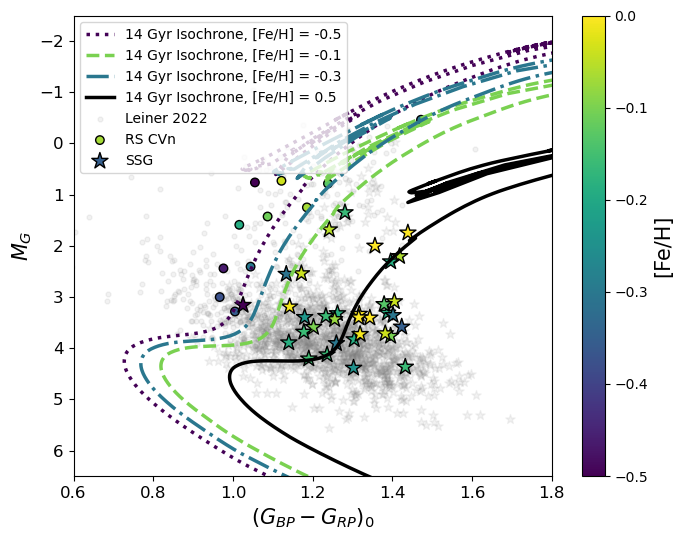

In [60]:
vmax0 = 0#0.25 #0.00#max(metallicity[in_rv_samp])
vmin0 = -0.50#min(metallicity[in_rv_samp])
size = 50#None

iso_lw = 2.5

in_rv_samp = (gaia_data['in_rv_samp'] == True)

fig, ax = plt.subplots(1, figsize = (7,5.5))

#ax.set_title('Full CMD')

ax.plot(BP_RPlow05, G_low05, color = '#440256', ls = ':',
        label='14 Gyr Isochrone, [Fe/H] = -0.5', lw = iso_lw)
ax.plot(BP_RPlow01, G_low01, color = '#7AD151', 
        #'#F8E621', #'#21908D', 
        ls = '--', label='14 Gyr Isochrone, [Fe/H] = -0.1', lw = iso_lw)
ax.plot(BP_RPlow03, G_low03, color = '#2A778E', 
        ls = '-.', label='14 Gyr Isochrone, [Fe/H] = -0.3', lw = iso_lw)
ax.plot(BP_RP05, G_05, 
        color = 'black', ls = '-', label='14 Gyr Isochrone, [Fe/H] = 0.5', lw =iso_lw)

ax.scatter(bp_rp[ssgs == False], M_G[ssgs == False], zorder=-10,
            marker='.', alpha= 0.1,color = 'gray', label = 'Leiner 2022', s=size)#'RS CVns')
ax.scatter(bp_rp[ssgs], M_G[ssgs], marker = '*', 
              alpha = 0.1, color = 'grey', s=size) # label = ' ')

cs = ax.scatter(bp_rp[(ssgs == False) & in_rv_samp], 
                M_G[(ssgs == False) & in_rv_samp],  
                alpha=1, c = metallicity[(ssgs == False) & in_rv_samp],
                vmin = vmin0, vmax = vmax0, label = 'RS CVn', marker= '.', 
                cmap = 'viridis', edgecolor = 'black', s=150)
#ax.plot(100,100, label = ' ', ls = 'none')
ax.scatter(bp_rp[ssgs & in_rv_samp], M_G[ssgs & in_rv_samp], 
           c = metallicity[ssgs & in_rv_samp],
           marker='*', s=150,  alpha=1, vmin = vmin0, vmax = vmax0, 
           label = 'SSG', cmap = 'viridis', edgecolor = 'black')



ax.tick_params(axis='x', labelsize=12)  # X-axis tick labels
ax.tick_params(axis='y', labelsize=12)  # Y-axis tick labels

ax.set_xlim(0.6, 1.8)
ax.set_ylim(-2.5,6.5)
ax.invert_yaxis()
ax.set_xlabel('$(G_{BP}-G_{RP})_0$', fontsize=15)
ax.set_ylabel('$M_G$', fontsize=15)

cb = fig.colorbar(cs)
cb.set_label('[Fe/H]', fontsize=15)

legend = ax.legend()

fig.tight_layout()

fig.savefig('Wilkes2025_CMD_v5.png', dpi = 300) #

#Narrow X-axis
#make stars bigger 
#no title

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


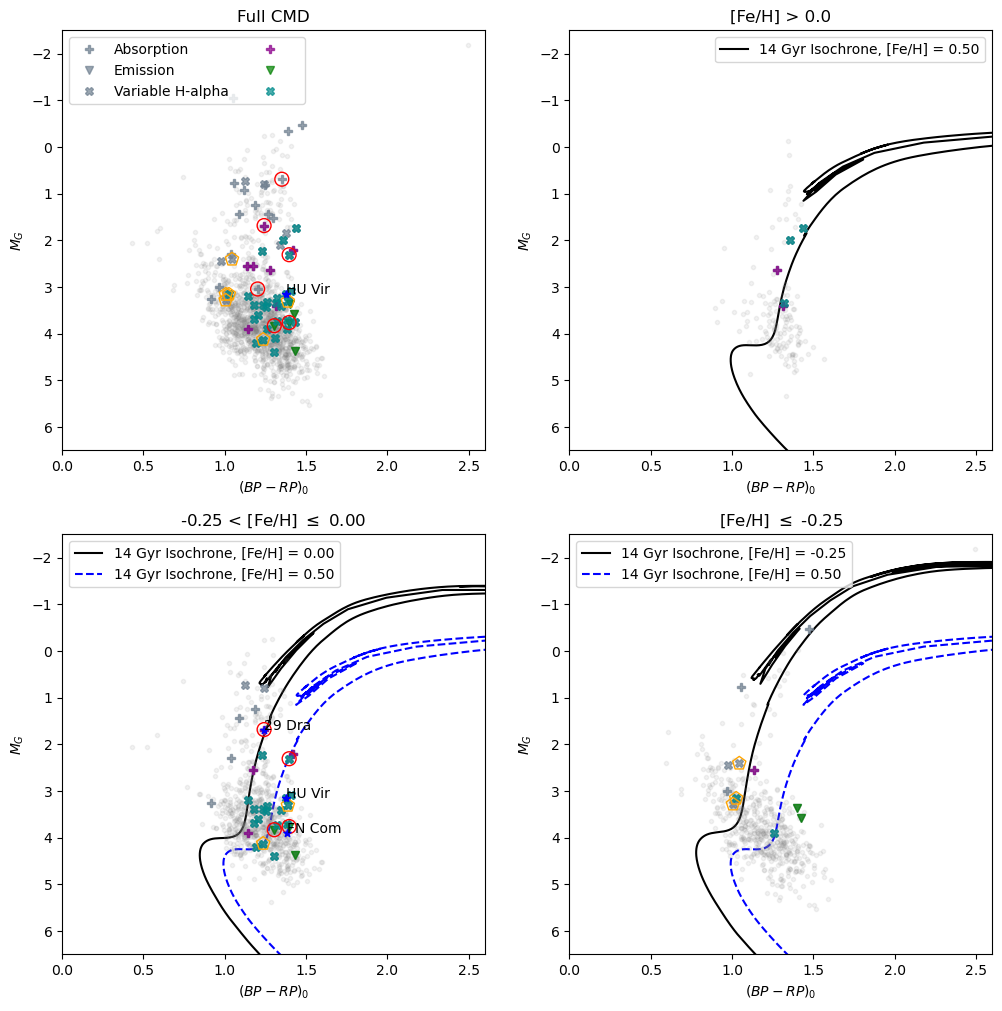

In [51]:
Halpha_ssgs = ((absorption & ssgs) | (emission & ssgs) | (ssgs & variable_ha))
halpha_prof = (absorption | emission | variable_ha)
grey_filt = ('slategrey', 'slategrey', 'slategrey')
all_stars = np.ones(len(gaia_data), dtype= bool)


low_rv = ((gaia_data['K1'] <= 1) & in_rv_samp)
sb2 = (gaia_data['Broadening Profile'] == 'SB2')

size = 30
fig, axes = four_plots()
(ax, ax2), (ax3, ax4) = axes
#Full Sample
Halpha_plots(ax, filters=all_stars,colors = grey_filt, 
             legend = True)
Halpha_plots(ax, filters=Halpha_ssgs, labels = [' ', ' ',' '])

ax.plot(bp_rp[HUVir], M_G[HUVir], marker='*', linestyle='none', 
        alpha=1, color = 'blue', zorder=12)
ax.text(bp_rp[HUVir], M_G[HUVir], 'HU Vir')

ax.scatter(bp_rp[low_rv & halpha_prof], M_G[low_rv & halpha_prof], 
           color= 'None', edgecolor = 'red', s = 100,
          zorder=10)
ax.scatter(bp_rp[sb2 & halpha_prof], M_G[sb2 & halpha_prof], 
           color= 'None', edgecolor = 'orange', s = 100, marker = 'p',
          zorder=10)


#Subsample #1
Halpha_plots(ax2, fe_h1b, colors = grey_filt, 
             legend = False, labels = [None, None,None])
Halpha_plots(ax2, fe_h1b & Halpha_ssgs, legend = False)

ax2.scatter(bp_rp[low_rv & halpha_prof & fe_h1b], M_G[low_rv & halpha_prof  & fe_h1b], 
           color= 'None', edgecolor = 'red', s = 100,
          zorder=10)
ax2.scatter(bp_rp[sb2 & halpha_prof & fe_h1b], M_G[sb2 & halpha_prof  & fe_h1b], 
           color= 'None', edgecolor = 'orange', s = 100, marker = 'p',
          zorder=10)

#Subsample #2
Halpha_plots(ax3, fe_h2b, colors = grey_filt, 
             legend = False, labels = [None, None,None])
Halpha_plots(ax3, fe_h2b & Halpha_ssgs, legend = False)

ax3.scatter(bp_rp[low_rv & halpha_prof & fe_h2b], M_G[low_rv & halpha_prof  & fe_h2b], 
           color= 'None', edgecolor = 'red', s = 100,
          zorder=10)
ax3.scatter(bp_rp[sb2 & halpha_prof & fe_h2b], M_G[sb2 & halpha_prof  & fe_h2b], 
           color= 'None', edgecolor = 'orange', s = 100, marker = 'p',
          zorder=10)

#Highlight Stars
ax3.plot(bp_rp[HUVir], M_G[HUVir], marker='*', linestyle='none', 
        alpha=1, color = 'blue', zorder=12)
ax3.text(bp_rp[HUVir], M_G[HUVir], 'HU Vir')


ax3.scatter(bp_rp[Dra29], M_G[Dra29], marker = '*', s = 30, alpha = 1, color = 'blue', zorder=12)
ax3.text(bp_rp[Dra29], M_G[Dra29], '29 Dra', zorder=12)

ax3.scatter(bp_rp[FNCom], M_G[FNCom], marker = '*', s = 30, alpha = 1, color = 'blue',zorder=12)
ax3.text(bp_rp[FNCom], M_G[FNCom], 'FN Com', zorder=12)


#Subsample #3
Halpha_plots(ax4, fe_h3b, colors = ('slategrey', 'slategrey', 'slategrey'), legend = False)
Halpha_plots(ax4,fe_h3b & Halpha_ssgs, legend = False)


ax4.scatter(bp_rp[low_rv & halpha_prof & fe_h3b], M_G[low_rv & halpha_prof & fe_h3b], 
           color= 'None', edgecolor = 'red', s = 100,
          zorder=10)
ax4.scatter(bp_rp[sb2 & halpha_prof & fe_h3b], M_G[sb2 & halpha_prof & fe_h3b], 
           color= 'None', edgecolor = 'orange', s = 100, marker = 'p',
          zorder=10)

ax.legend(ncols = 2)


In [ ]:
gaia_data[HUVir]

In [ ]:
print(np.log10(14e9), np.log(14e9), 10**10.3)

In [30]:
old_ssg = (gaia_data['leiner_class'] == 'SSG')
old_rs = (gaia_data['leiner_class'] == 'RS')
old_cut = (gaia_data['leiner_class'] == 'cut')

print('Leiner SSG', len(gaia_data[old_ssg]))
print('Leiner RS', len(gaia_data[old_rs]))
print('Leiner Cut', len(gaia_data[old_cut]))

Leiner SSG 448
Leiner RS 1275
Leiner Cut 172
